Importamos los datos del famoso problema de los Irises, desde el archivo de la UCI, mediante pandas

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']

dataset = pd.read_csv(url,names=names)

Normalización de los datos, usando normalización estándar

In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = dataset.values[:,0:4]
y = dataset.values[:,4]

scaler.fit(X)
Z = scaler.transform(X)

Comparamos distintos modelos usando k-folds

Method Linear Discriminant Analysis: mean 0.979333 std(0.023935)
Method K-Nearest Neighbors.........: mean 0.962000 std(0.027495)
Method Desicion Tree Classifier....: mean 0.946000 std(0.038810)
Method Gaussian Naive Bayes........: mean 0.954667 std(0.036974)
Method Support Vector Machine......: mean 0.959333 std(0.032173)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Method Multi Layer Perceptron......: mean 0.960667 std(0.037529)


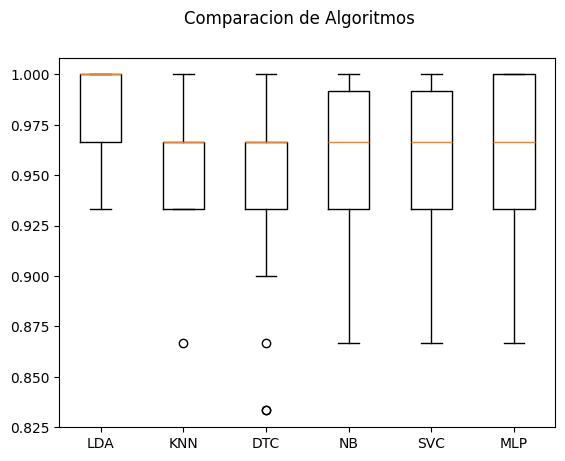

In [3]:
import matplotlib.pyplot as plt
from sklearn import model_selection

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

names = ["LDA", "KNN", "DTC", "NB", "SVC", "MLP"]

models = [('Linear Discriminant Analysis', LinearDiscriminantAnalysis()),
          ('K-Nearest Neighbors.........', KNeighborsClassifier(n_neighbors=6)),
          ('Desicion Tree Classifier....', DecisionTreeClassifier()),
          ('Gaussian Naive Bayes........', GaussianNB()),
          ('Support Vector Machine......', SVC(gamma='auto')),
          ('Multi Layer Perceptron......', MLPClassifier(solver='lbfgs', hidden_layer_sizes=10, max_iter=10000))]

results = []


for name, model in models:
    kfold = model_selection.RepeatedStratifiedKFold(n_splits=5, n_repeats=10)
    cv_results = model_selection.cross_val_score(model, Z, y, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    msg = "Method %s: mean %f std(%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

fig = plt.figure()
fig.suptitle('Comparacion de Algoritmos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

Calculamos las métricas de modelo de Análisis de Discriminantes Lineales (LDA)
Y Desplegamos la matriz de confusión y reporte de clasificación  correspondientes

In [4]:
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

validation_size = 0.20
z_train, z_validation, y_train, y_validation = model_selection.train_test_split(Z, y, test_size=validation_size,stratify=y)

lda = LinearDiscriminantAnalysis()
lda.fit(z_train, y_train)
predictions = lda.predict(z_validation)
print("Linear Discriminant Analysis")
print(accuracy_score(y_validation, predictions))
print(confusion_matrix(y_validation, predictions))
print(classification_report(y_validation, predictions))

Linear Discriminant Analysis
1.0
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

